# CIFAR-100 — Custom ResNeXt-50 (32×4d)

A custom implementation of **ResNeXt-50 (32×4d)** adapted for CIFAR-100’s 32×32 input.

ResNeXt ([Xie et al., 2017](https://arxiv.org/abs/1611.05431)) extends ResNet
by replacing standard bottleneck blocks with **grouped convolutions**,
introducing a *cardinality* dimension (C = number of parallel paths).

| Hyper-parameter | Value |
|-----------------|-------|
| Cardinality (C) | 32    |
| Bottleneck width (d) | 4 |
| Grouped-conv width per stage | C × d × (planes / 64) |
| Layer config    | [3, 4, 6, 3] |
| Expansion       | 4     |

Uses a CIFAR-friendly 3×3 stem (no 7×7 conv or initial max-pooling).

## Imports

In [1]:
import sys
sys.path.append('../..')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim

from utils.dataset import get_cifar100_dataloaders, CIFAR100_CLASSES
from utils.training import fit, test_accuracy
from utils.callbacks import ModelCheckpoint
from utils.plotting import plot_training_curves, show_sample_batch
import torchvision.transforms as transforms


## Device Setup

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cuda':
    torch.backends.cudnn.benchmark = True
print(f'Using device: {device}')

Using device: cuda


## Data Pipeline

In [3]:
batch_size = 128

trainloader, valloader, testloader = get_cifar100_dataloaders(
    batch_size=batch_size, num_workers=4, img_size=224, interpolation=transforms.InterpolationMode.BICUBIC
)

print(f'Train batches: {len(trainloader)} | Val batches: {len(valloader)} | Test batches: {len(testloader)}')

C:\Users\asmit\PycharmProjects\CIFAR_10\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Train batches: 313 | Val batches: 79 | Test batches: 79


## Visualize Sample Batch

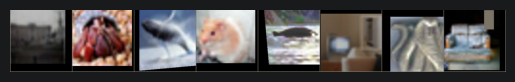

castle crab  whale hamster whale television snake couch


In [4]:
show_sample_batch(trainloader, CIFAR100_CLASSES)

## Model Definition

### ResNeXtBottleneck
The grouped bottleneck block:
1. **1×1 conv** — project from `in_planes` down to `width = C × d × (planes / 64)`
2. **3×3 grouped conv** — `groups = C` (cardinality)
3. **1×1 conv** — expand back to `planes × expansion`

With C=32, d=4 the widths per stage are 128 → 256 → 512 → 1024,
each split into 32 parallel 4/8/16/32-wide paths.

### ResNeXt50
4 stages with [3, 4, 6, 3] `ResNeXtBottleneck` blocks — ~25M parameters.
Uses a CIFAR-friendly 3×3 stem (stride-1, no initial max-pooling).

In [5]:
class ResNeXtBottleneck(nn.Module):
    """
    ResNeXt Bottleneck block with grouped convolutions.

    Architecture:  1×1 → 3×3 (groups=cardinality) → 1×1
    The intermediate width is: cardinality * base_width * (planes // 64)
    """
    expansion = 4

    def __init__(self, in_planes, planes, stride=1,
                 cardinality=32, base_width=4):
        super().__init__()
        # Grouped-conv width:  C * d * (planes / 64)
        width = int(planes * (base_width / 64.0)) * cardinality

        # 1×1 reduce
        self.conv1 = nn.Conv2d(in_planes, width, kernel_size=1, bias=False)
        self.bn1   = nn.BatchNorm2d(width)

        # 3×3 grouped conv
        self.conv2 = nn.Conv2d(
            width, width, kernel_size=3,
            stride=stride, padding=1,
            groups=cardinality, bias=False
        )
        self.bn2   = nn.BatchNorm2d(width)

        # 1×1 expand
        self.conv3 = nn.Conv2d(width, self.expansion * planes, kernel_size=1, bias=False)
        self.bn3   = nn.BatchNorm2d(self.expansion * planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_planes, self.expansion * planes,
                    kernel_size=1, stride=stride, bias=False
                ),
                nn.BatchNorm2d(self.expansion * planes),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = F.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class ResNeXt50(nn.Module):
    """
    ResNeXt-50 (32×4d) adapted for CIFAR (32×32 input, 3×3 stem).

    Args:
        num_classes:  Number of output classes (default: 100).
        cardinality:  Number of parallel paths / groups (default: 32).
        base_width:   Per-group bottleneck width (default: 4).
    """
    def __init__(self, num_classes=100, cardinality=32, base_width=4):
        super().__init__()
        self.in_planes   = 64
        self.cardinality = cardinality
        self.base_width  = base_width

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # 4 stages with [3, 4, 6, 3] Bottleneck blocks
        self.layer1 = self._make_layer(64,  3, stride=1)
        self.layer2 = self._make_layer(128, 4, stride=2)
        self.layer3 = self._make_layer(256, 6, stride=2)
        self.layer4 = self._make_layer(512, 3, stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * ResNeXtBottleneck.expansion, num_classes)

    def _make_layer(self, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers  = []
        for s in strides:
            layers.append(
                ResNeXtBottleneck(
                    self.in_planes, planes, s,
                    cardinality=self.cardinality,
                    base_width=self.base_width,
                )
            )
            self.in_planes = planes * ResNeXtBottleneck.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.maxpool(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

## Initialize Model & Print Summary

In [6]:
model = ResNeXt50(num_classes=100, cardinality=32, base_width=4).to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

ResNeXt50(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): ResNeXtBottleneck(
      (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(128, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNor

## Training Configuration

In [7]:
criterion = nn.CrossEntropyLoss()
epochs = 90
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)

# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=0.1,
    steps_per_epoch=len(trainloader),
    epochs=epochs,
    pct_start=0.10,
    anneal_strategy='cos',
    div_factor=10,
    final_div_factor=1e4,
)


scaler = torch.amp.GradScaler('cuda')
NAME = 'resnext50_32x4d_100'
checkpoint = ModelCheckpoint(
    model=model,
    checkpoint_path=f'../../checkpoint/{NAME}_latest.pth',
    best_model_path=f'../../checkpoint/{NAME}_best.pth',
    mode='max',
    verbose=False,
)

## Training Loop

In [8]:
train_losses, val_losses, val_accuracies = fit(
    model, trainloader, valloader, criterion,
    optimizer, scheduler, scaler, device, epochs, checkpoint,
    step_scheduler_per_batch=True, log=True
)

[RunLogger] Logging to 'C:\Users\asmit\PycharmProjects\CIFAR_10\logs\9755208/'  —  run: 'resnext50_20260608_090740'
Epoch [ 1/90]  Train Loss: 4.4899  Val Loss: 3.9867  Val Acc: 7.20%  LR: 0.011206  Time: 73.24s
Epoch [ 2/90]  Train Loss: 4.0133  Val Loss: 3.6419  Val Acc: 12.45%  LR: 0.014774  Time: 56.42s
Epoch [ 3/90]  Train Loss: 3.7316  Val Loss: 3.5417  Val Acc: 16.03%  LR: 0.020490  Time: 56.13s
Epoch [ 4/90]  Train Loss: 3.3372  Val Loss: 3.1765  Val Acc: 21.82%  LR: 0.028082  Time: 55.39s
Epoch [ 5/90]  Train Loss: 2.9963  Val Loss: 2.7067  Val Acc: 30.26%  LR: 0.037126  Time: 55.54s
Epoch [ 6/90]  Train Loss: 2.6694  Val Loss: 2.5078  Val Acc: 34.92%  LR: 0.047135  Time: 55.49s
Epoch [ 7/90]  Train Loss: 2.3780  Val Loss: 2.2909  Val Acc: 40.48%  LR: 0.057567  Time: 55.79s
Epoch [ 8/90]  Train Loss: 2.1461  Val Loss: 2.5170  Val Acc: 38.49%  LR: 0.067861  Time: 56.53s
Epoch [ 9/90]  Train Loss: 1.9739  Val Loss: 2.1399  Val Acc: 45.29%  LR: 0.077461  Time: 55.50s
Epoch [10/90

## Restore Best Weights & Test Evaluation

In [9]:
checkpoint.restore_best_weights()

overall_acc, per_class = test_accuracy(model, testloader, CIFAR100_CLASSES, device)
print(f'\nOverall Test Accuracy: {overall_acc:.2f}%\n')
for name, acc in per_class.items():
    print(f'  {name:5s}: {acc:.1f}%')


Overall Test Accuracy: 78.12%

  apple: 89.0%
  aquarium_fish: 90.0%
  baby : 70.0%
  bear : 63.0%
  beaver: 66.0%
  bed  : 85.0%
  bee  : 82.0%
  beetle: 80.0%
  bicycle: 90.0%
  bottle: 87.0%
  bowl : 57.0%
  boy  : 54.0%
  bridge: 83.0%
  bus  : 75.0%
  butterfly: 77.0%
  camel: 84.0%
  can  : 80.0%
  castle: 87.0%
  caterpillar: 72.0%
  cattle: 68.0%
  chair: 90.0%
  chimpanzee: 90.0%
  clock: 80.0%
  cloud: 85.0%
  cockroach: 85.0%
  couch: 70.0%
  crab : 66.0%
  crocodile: 73.0%
  cup  : 82.0%
  dinosaur: 75.0%
  dolphin: 73.0%
  elephant: 75.0%
  flatfish: 73.0%
  forest: 62.0%
  fox  : 91.0%
  girl : 54.0%
  hamster: 86.0%
  house: 81.0%
  kangaroo: 77.0%
  keyboard: 94.0%
  lamp : 77.0%
  lawn_mower: 88.0%
  leopard: 82.0%
  lion : 87.0%
  lizard: 63.0%
  lobster: 64.0%
  man  : 60.0%
  maple_tree: 69.0%
  motorcycle: 92.0%
  mountain: 91.0%
  mouse: 63.0%
  mushroom: 83.0%
  oak_tree: 72.0%
  orange: 94.0%
  orchid: 86.0%
  otter: 57.0%
  palm_tree: 90.0%
  pear : 79.0%
  pi

## Training Curves

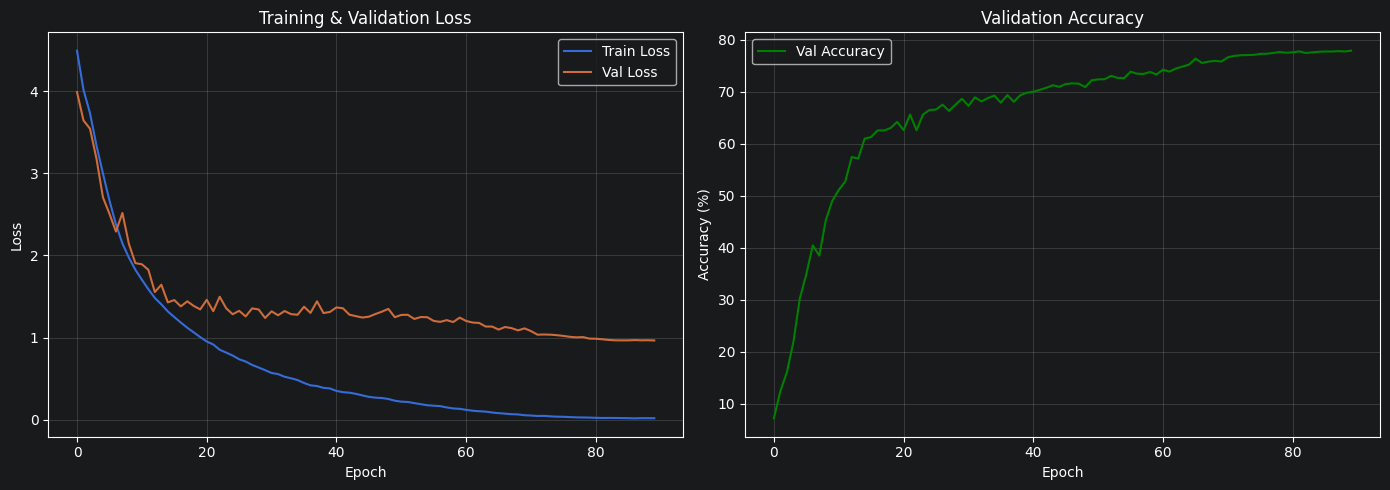

In [10]:
plot_training_curves(train_losses, val_losses, val_accuracies)